# Exponential Propagators for the Time-Dependent Schrödinger Equation

This notebook studies numerical time propagation of the one-dimensional time-dependent Schrödinger equation (TDSE) using several approximations of the matrix exponential. The evolution of a time-independent quantum system is governed by

$$
i\frac{\partial \Psi(x,t)}{\partial t} = H\Psi(x,t),
$$

with the Hamiltonian

$$
H = K + V,
$$

where, in the dimensionless units used throughout this notebook,

$$
K = -\frac{1}{2}\frac{\partial^2}{\partial x^2}.
$$

For a time-independent Hamiltonian, the exact formal solution is

$$
\Psi(x,t) = e^{-iHt}\Psi(x,0).
$$

Therefore, after spatial discretization, the central numerical problem becomes the evaluation of the matrix exponential

$$
e^{-iH\Delta t}.
$$

The main objective of this notebook is to compare three exponential approximations:

- truncated Taylor approximation,
- inverse-Taylor approximation,
- diagonal Padé approximation,

with scaling and squaring applied to all three approaches.

Two physical problems are used as numerical benchmarks:

1. the harmonic oscillator, where the expectation value $\langle x\rangle$ has a known analytical solution;
2. quantum tunnelling through a finite potential barrier, where the transmission coefficient can be compared with an analytical expression.

The spatial derivative is approximated using high-order central differences, allowing the effects of spatial discretization order to be studied separately from the choice of exponential propagator.

## Background and References

The numerical approach used in this notebook developed progressively from earlier work on high-order numerical methods for the time-dependent Schrödinger equation. The starting point was a high-order finite-difference approach for quantum tunnelling, where the spatial derivatives were approximated using higher-order central differences:

*[Simulation of Quantum Tunnelling in Semiconductors: Analysis of Barrier Thickness Variation through the High Order FDTD Method](https://doi.org/10.26418/positron.v14i2.82415)*

The next step was to improve the approximation of the time-evolution operator. Instead of using the standard Crank–Nicolson formulation, the exponential propagator was approximated using a higher-order Taylor expansion. This led to a symmetric form of the approximation, which was developed in:

*[Modified Crank-Nicolson method for solving the time-dependent Schrödinger equation](https://doi.org/10.1088/1742-6596/2900/1/012009)*

While studying higher-order exponential approximations further, Padé approximation provided a more systematic rational approximation to the exponential. This motivated extending the previous approach by comparing the direct Taylor approximation and Padé approximation within the same framework. The treatment of Padé approximations and their stability properties is supported by:

*[A-Stable Methods and Padé Approximations to the Exponential](https://doi.org/10.1137/0504057)*

*[Accurate numerical solutions of the time-dependent Schrödinger equation](https://doi.org/10.1103/PhysRevE.75.036707)*

The final step was incorporating scaling and squaring to improve the computation of the matrix exponential for larger matrix arguments:

*[A New Scaling and Squaring Algorithm for the Matrix Exponential](https://doi.org/10.1137/09074721X)*

Thus, the development of this notebook can be viewed as a progression:

**high-order finite differences → high-order Taylor approximation → Padé approximation → scaling and squaring**

The purpose of this notebook is not to reproduce any single method from these references. Instead, it brings these approximations into a common computational framework and compares their numerical behavior under the same spatial discretization, time evolution, and physical test problems.

In [1]:
from time import time
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 16 })

## Spatial Discretization

The continuous Hamiltonian contains the second spatial derivative,

$$
H = -\frac{1}{2}\frac{\partial^2}{\partial x^2} + V(x).
$$

To obtain a finite-dimensional matrix representation, the spatial domain is discretized as

$$
x_j = x_0 + j\Delta x.
$$

Rather than using the standard three-point second-order stencil, a symmetric high-order central-difference stencil is constructed. For an even spatial order $n$,

$$
\frac{\partial^2\Psi(x)}{\partial x^2}\approx\frac{1}{\Delta x^2}\sum_{j=-n/2}^{n/2} c_{|j|}\Psi(x + j\Delta x).
$$

The coefficients are obtained by imposing the corresponding moment conditions:

$$
\begin{bmatrix}
1 & 2 & 2 & \cdots & 2\\
0 & 1 & 2^2 & \cdots & (n/2)^2\\
0 & 1 & 2^4 & \cdots & (n/2)^4\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
0 & 1 & 2^n & \cdots & (n/2)^n
\end{bmatrix}
\begin{bmatrix}
c_0\\
c_1\\
c_2\\
\vdots\\
c_{n/2}
\end{bmatrix}
=
\begin{bmatrix}
0\\
1\\
0\\
\vdots\\
0
\end{bmatrix}.
$$

This construction allows the spatial discretization order to be increased without manually specifying the stencil coefficients. The resulting differentiation matrix is then scaled by $\Delta x^{-2}$ when constructing the Hamiltonian. The implementation uses a periodic stencil, so points crossing either boundary are wrapped around to the opposite side of the spatial domain.

In [3]:
def centralDiff2(order, N):
    n = order // 2
    j = np.arange(n + 1)
    A = np.vstack([np.ones(n + 1), *[j**(2 * i) for i in range(1, n + 1)]])
    A[0, 1:] *= 2
    b = np.zeros(n + 1)
    b[1] = 1
    c = np.linalg.solve(A, b)
    D = np.diag(c[0] * np.ones(N), 0)
    for k in range(1, n + 1):
        D += np.diag(c[k] * np.ones(N - k), k)
        D += np.diag(c[k] * np.ones(N - k), -k)
        D += np.diag(c[k] * np.ones(k), N - k)
        D += np.diag(c[k] * np.ones(k), -(N - k))
    return D

### Discrete Hamiltonian

After spatial discretization, the Hamiltonian becomes a finite-dimensional matrix,

$$
H = -\frac{1}{2\Delta x^2}D_{xx} + V,
$$

where $D_{xx}$ is the dimensionless finite-difference matrix and

$$
V = \operatorname{diag}\left(V(x_0), V(x_1), \ldots, V(x_{N-1})\right).
$$

The continuous TDSE is therefore transformed into a matrix differential equation,

$$
i\frac{d\boldsymbol{\Psi}}{dt} = H\boldsymbol{\Psi}.
$$

Its exact one-step propagation is

$$
\boldsymbol{\Psi}(t + \Delta t) = e^{-iH\Delta t}\boldsymbol{\Psi}(t).
$$

The remaining problem is therefore the numerical approximation of this matrix exponential.

## Exponential Propagators

The exact time-evolution operator over one time step is

$$
U(\Delta t) = e^{-iH\Delta t}.
$$

Direct evaluation of a dense matrix exponential can be computationally expensive for the matrix sizes considered here. Instead, the exponential is approximated using several finite-order representations.

All methods in this notebook use the same scaling-and-squaring framework. Therefore, the comparison focuses on the different approximations to $e^{-iH\Delta t}$ while keeping the scaling strategy consistent.

### Taylor Approximation

The exponential is approximated by truncating its Taylor series at order $n$:

$$
e^{-iH\Delta t}\approx\sum_{k=0}^{n}\frac{(-iH\Delta t)^k}{k!}.
$$

Increasing $n$ retains more terms of the series and yields a higher-order approximation to the propagator. This is the direct high-order exponential approximation developed from the earlier numerical formulation.

### Scaling and Squaring

For large matrix arguments, a low-order approximation may become inaccurate. Scaling and squaring addresses this by first reducing the magnitude of the matrix argument and then recovering the full exponential through repeated squaring. Using

$$
e^{-iH\Delta t} = \left(e^{-iH\Delta t/2^s}\right)^{2^s},
$$

the exponential is approximated as

$$
e^{-iH\Delta t}\approx\left[R\left(-\frac{iH\Delta t}{2^s}\right)\right]^{2^s},
$$

where $R$ represents the chosen finite-order approximation. In this implementation, the scaling parameter is determined from the matrix 1-norm:

$$
s = \max\left(0, \left\lceil\log_2\left\|-iH\Delta t\right\|_1\right\rceil\right).
$$

The same scaling-and-squaring procedure is applied to the Taylor, inverse-Taylor, and Padé approximations, providing a common framework for their comparison.

In [4]:
def taylorExp(x, order):
    s = max(0, int(np.ceil(np.log2(np.linalg.norm(x, 1)))))
    x = x / (2 ** s)
    N = x.shape[0]
    E = np.eye(N, dtype=complex)
    X = np.eye(N, dtype=complex)
    for k in range(1, order + 1):
        X = X @ x
        E += X / sp.special.factorial(k)
    return np.linalg.matrix_power(E, 2**s)

### Inverse-Taylor Approximation

The inverse-Taylor approximation is obtained by approximating the exponential in the denominator with a truncated Taylor series:

$$
e^{-iH\Delta t} = \frac{1}{e^{iH\Delta t}} \approx \left(\sum_{k=0}^{n}\frac{(iH\Delta t)^k}{k!}\right)^{-1}.
$$

Increasing $n$ provides a higher-order approximation to the exponential while retaining the inverse form of the propagator.

In [5]:
def taylorExpInverse(x, order):
    s = max(0, int(np.ceil(np.log2(np.linalg.norm(x, 1)))))
    x = x / (2 ** s)
    N = x.shape[0]
    E = np.eye(N, dtype=complex)
    X = np.eye(N, dtype=complex)
    for k in range(1, order + 1):
        X = X @ x
        E += (-1)**k * X / sp.special.factorial(k)
    return np.linalg.matrix_power(np.linalg.solve(E, np.eye(E.shape[0])), 2**s)

### Padé Approximation

Unlike the Taylor approximation, which uses a polynomial, the Padé approximation represents the exponential as a rational function. For the diagonal $[m/m]$ approximant,

$$
e^{-iH\Delta t} \approx P_m(-iH\Delta t)\,Q_m(-iH\Delta t)^{-1},
$$

where

$$
P_m(-iH\Delta t) = \sum_{k=0}^{m}c_k(-iH\Delta t)^k,
$$

and

$$
Q_m(-iH\Delta t) = \sum_{k=0}^{m}(-1)^k c_k(-iH\Delta t)^k.
$$

The coefficients are given by

$$
c_k = \frac{(2m-k)!\,m!}{(2m)!\,k!\,(m-k)!}.
$$

For the even orders used in this notebook, $n = 4, 6, 8$ corresponds to the diagonal Padé approximants $[2/2]$, $[3/3]$, and $[4/4]$, respectively. The Padé approximation is combined with the same scaling-and-squaring procedure described above.

In [6]:
def padeExp(x, order):
    m = order // 2
    s = max(0, int(np.ceil(np.log2(np.linalg.norm(x, 1)))))
    x = x / (2 ** s)
    N = x.shape[0]
    P = np.eye(N, dtype=complex)
    Q = np.eye(N, dtype=complex)
    X = np.eye(N, dtype=complex)
    for k in range(1, m + 1):
        X = X @ x
        coeff = (sp.special.factorial(2 * m - k) * sp.special.factorial(m)
                 / (sp.special.factorial(2 * m) * sp.special.factorial(k) * sp.special.factorial(m - k)))
        P += coeff * X
        Q += (-1)**k * coeff * X
    return np.linalg.matrix_power(np.linalg.solve(Q, P), 2**s)

In [7]:
methods = {
    "Taylor": taylorExp,
    "Inverse-Taylor": taylorExpInverse,
    "Pade": padeExp
}

## Benchmark I: Harmonic Oscillator

The first benchmark considers the one-dimensional harmonic oscillator with

$$
V(x) = \frac{1}{2}x^2.
$$

The initial state is a Gaussian wave packet with $x_0 = 20$ and $\sigma = 1$:

$$
\Psi(x,0) = \frac{1}{\pi^{1/4}}\exp\left[-\frac{(x-20)^2}{2}\right].
$$

For this initial condition, the analytical expectation value of position is

$$
{\langle x\rangle}_{\mathrm{exact}} = 20\cos t.
$$

The numerical expectation value is computed from the propagated probability density as

$$
{\langle x\rangle}_{\mathrm{num}} = \frac{\int x|\Psi(x,t)|^2\,dx}{\int |\Psi(x,t)|^2\,dx}.
$$

The explicit normalization is retained to account for small numerical deviations in the wavefunction norm.

In [8]:
PSI = lambda x, x0, sigma: np.exp(-0.5 * ((x - x0) / sigma)**2) / np.sqrt(sigma * np.sqrt(np.pi))
V = lambda x: 0.5 * x**2
H = lambda V, order: -0.5 * centralDiff2(order, x.size) / dx**2 + np.diag(V(x))
X = lambda x0, t: x0 * np.cos(t)

In [9]:
N = np.array([1001, 2001])
orders = np.arange(4, 9, 2)

Psi = {method: {order: {} for order in orders} for method in methods}
Prob = {method: {order: {} for order in orders} for method in methods}
ExpectX = {method: {order: {} for order in orders} for method in methods}
ExecutionTime = {method: {order: {} for order in orders} for method in methods}
Error = {method: {order: {} for order in orders} for method in methods}
RMSE = {method: {order: {} for order in orders} for method in methods}

for order in orders:
    for n in N:
        x, dx = np.linspace(-40, 40, n, retstep=True)
        t, dt = np.linspace(0, 10, n, retstep=True)
        ExactX = X(20, t)
        h = H(V, order)
        for method, exp in methods.items():
            start_time = time()
            u = exp(-1j * h * dt, order)
            psi = PSI(x, 20, 1)
            psi_history = np.zeros((len(t), len(x)), dtype=complex)
            prob_history = np.zeros((len(t), len(x)))
            psi_history[0] = psi
            prob_history[0] = np.abs(psi)**2
            for i in range(1, len(t)):
                psi = u @ psi
                psi_history[i] = psi
                prob_history[i] = np.abs(psi)**2
            ExecutionTime[method][order][n] = time() - start_time
            ExpectX[method][order][n] = (sp.integrate.simpson(x * prob_history, x=x, axis=1)
                                         / sp.integrate.simpson(prob_history, x=x, axis=1))
            Psi[method][order][n] = psi_history
            Prob[method][order][n] = prob_history
            Error[method][order][n] = ExpectX[method][order][n] - ExactX
            RMSE[method][order][n] = np.sqrt(sp.integrate.simpson(Error[method][order][n]**2, x=t) / (t[-1] - t[0]))

### Error and Convergence

The pointwise error in the expectation value is defined as

$$
E(t) = {\langle x\rangle}_{\mathrm{num}} - {\langle x\rangle}_{\mathrm{exact}}.
$$

To summarize the error over the entire simulation interval, the root-mean-square error is used:

$$
\mathrm{RMSE} = \sqrt{\frac{1}{T}\int_0^T E(t)^2\,dt}.
$$

The calculation is repeated for spatial grids with

$$
N = 1001\quad
\text{and}\quad
N = 2001
$$

and for spatial finite-difference orders

$$
n = 4,\; 6,\; 8.
$$

The resulting empirical convergence rate is estimated from

$$
p = \frac{\log(E_1/E_2)}{\log(\Delta x_1/\Delta x_2)}.
$$

Because the current implementation defines the temporal grid using the same number of points as the spatial grid, changing $N$ simultaneously changes both $\Delta x$ and $\Delta t$. Therefore, this quantity should be interpreted as an empirical convergence rate under simultaneous spatial and temporal refinement, rather than as a pure spatial convergence measurement.

In [10]:
rows = []
for method in methods:
    for order in orders:
        rows.append({
            "Method": method,
            "Order": order,
            "RMSE N=1001": RMSE[method][order][1001],
            "RMSE N=2001": RMSE[method][order][2001],
            "Convergence Order": np.log(RMSE[method][order][1001] / RMSE[method][order][2001]) / np.log((2001 - 1) / (1001 - 1)),
            "Time N=1001": ExecutionTime[method][order][1001],
            "Time N=2001": ExecutionTime[method][order][2001],
        })
pd.DataFrame(rows)

,Method,Order,RMSE N=1001,RMSE N=2001,Convergence Order,Time N=1001,Time N=2001
0,Taylor,4,4.818216,0.313243,3.943146,2.212193,9.849271
1,Taylor,6,1.777511,0.036121,5.620894,1.505260,12.237442
2,Taylor,8,0.730796,0.004488,7.347229,2.126789,14.495819
3,Inverse-Taylor,4,4.818625,0.313243,3.943268,2.174758,18.220167
4,Inverse-Taylor,6,1.777511,0.036121,5.620893,2.881388,17.373484
5,Inverse-Taylor,8,0.730796,0.004488,7.347229,3.427596,19.855597
6,Pade,4,4.817783,0.313201,3.943208,1.955890,15.488653
7,Pade,6,1.777512,0.036121,5.620894,2.424069,15.740203
8,Pade,8,0.730796,0.004488,7.347229,2.820607,17.950943


## Benchmark II: Quantum Tunnelling

The second benchmark considers a Gaussian wave packet incident on a finite potential barrier,

$$
V(x) =
\begin{cases}
V_0, & x_1\leq x\leq x_2,\\
0, & \text{otherwise}.
\end{cases}
$$

The initial wave packet is

$$
\Psi(x,0) = \frac{1}{\pi^{1/4}}\exp\left[-\frac{(x+5)^2}{2} + 10ix\right].
$$

The corresponding incident energy is

$$
E = \frac{10^2}{2} = 50.
$$

The analytical transmission coefficient for a rectangular barrier with $E < V_0$ is

$$
T = \frac{4E(V_0-E)}{V_0^2\sinh^2\left(l\sqrt{2(V_0-E)}\right) + 4E(V_0-E)},
$$

where $l = x_2 - x_1$ is the barrier width.

The numerical transmission probability is obtained by integrating the probability density to the right of the barrier,

$$
T_{\mathrm{num}}\approx\int_{x\geq x_2}|\Psi(x,t_f)|^2\,dx.
$$

The numerical result is then compared directly with the analytical transmission coefficient.

In [11]:
PSI = lambda x, x0, k, sigma: np.exp(-0.5 * ((x - x0) / sigma)**2 + 1j * k * x) / np.sqrt(sigma * np.sqrt(np.pi))
V = lambda x, x1, x2, V0: np.where((x >= x1) & (x <= x2), V0, 0.0)
T = lambda E, V, a: 4 * E * (V - E) / (4 * E * (V - E) + (V * np.sinh(a * np.sqrt(2 * (V - E))))**2)
H = lambda V, order: -0.5 * centralDiff2(order, x.size) / dx**2 + np.diag(V(x))

In [12]:
x, dx = np.linspace(-10, 10, 1000, retstep=True)
t, dt = np.linspace(0, 1, 1001, retstep=True)
order = 8

### Barrier Thickness Variation

First, the barrier height is fixed at

$$
V_0 = 100,
$$

while the barrier width is varied over

$$
0\leq l\leq0.4.
$$

For each value of $l$, the wave packet is propagated to the final simulation time and the transmitted probability is evaluated.

In [13]:
lengths = np.linspace(0, 0.4, 21)
Psi = {method: {} for method in methods}
Prob = {method: {} for method in methods}
Transmitted = {method: {} for method in methods}
ExecutionTime = {method: {} for method in methods}
Exact = {}
for length in lengths:
    v = lambda x: V(x, 0, length, 100)
    h = H(v, order)
    Exact[length] = T(50, 100, length)
    for method, exp in methods.items():
        start_time = time()
        u = exp(-1j * h * dt, order)
        psi = PSI(x, -5, 10, 1)
        for _ in range(len(t) - 1):
            psi = u @ psi
        end_time = time()
        prob = np.abs(psi)**2
        transmitted = sp.integrate.simpson(prob[x >= length], x=x[x >= length])
        Psi[method][length] = psi
        Prob[method][length] = prob
        Transmitted[method][length] = transmitted
        ExecutionTime[method][length] = end_time - start_time

In [14]:
Error = {method: np.array([Transmitted[method][length] - Exact[length] for length in lengths]) for method in methods}
RMSE = {method: np.sqrt(sp.integrate.simpson(Error[method]**2, x=lengths) / (lengths[-1] - lengths[0])) for method in methods}

In [15]:
print(RMSE)

{'Taylor': np.float64(0.001529960298922122), 'Inverse-Taylor': np.float64(0.0015299602984885745), 'Pade': np.float64(0.0015299602980611842)}


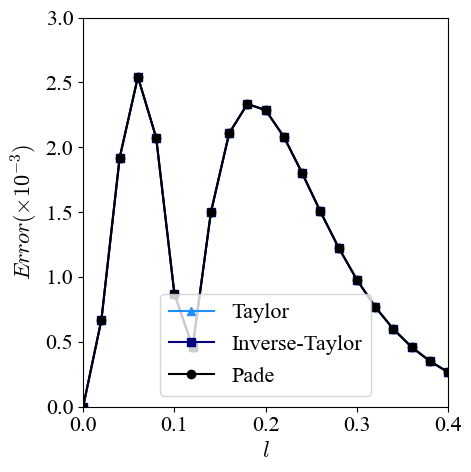

In [16]:
plt.figure(figsize=(5, 5))
plt.plot(lengths, np.abs(Error["Taylor"]) * 1000, "^-", color="dodgerblue", label="Taylor")
plt.plot(lengths, np.abs(Error["Inverse-Taylor"]) * 1000, "s-", color="navy", label="Inverse-Taylor")
plt.plot(lengths, np.abs(Error["Pade"]) * 1000, "o-", color="k", label="Pade")
plt.xlabel(r"$l$")
plt.xlim(0, 0.4)
plt.ylabel(r"$Error (\times 10^{-3})$")
plt.ylim(0, 3)
plt.legend()
plt.tight_layout()
plt.show()

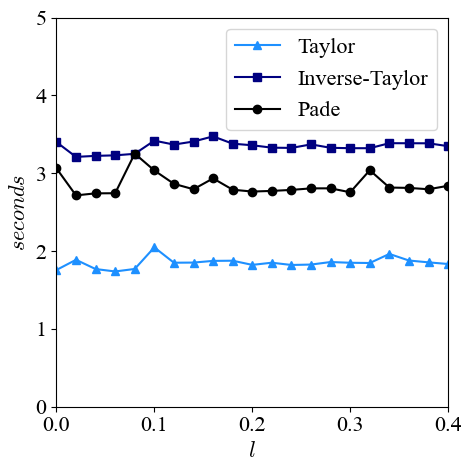

In [17]:
plt.figure(figsize=(5, 5))
plt.plot(lengths, [ExecutionTime["Taylor"][length] for length in lengths], "^-", color="dodgerblue", label="Taylor")
plt.plot(lengths, [ExecutionTime["Inverse-Taylor"][length] for length in lengths], "s-", color="navy", label="Inverse-Taylor")
plt.plot(lengths, [ExecutionTime["Pade"][length] for length in lengths], "o-", color="k", label="Pade")
plt.xlabel(r"$l$")
plt.xlim(0, 0.4)
plt.ylabel(r"$seconds$")
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()

### Barrier Height Variation

The second tunnelling experiment fixes the barrier width at

$$
l = 0.1
$$

and varies the barrier height over

$$
V_0 = 60, 70, \ldots, 250.
$$

This experiment tests the exponential propagators under a range of barrier strengths rather than at a single potential configuration.

In [18]:
V0 = np.arange(60, 251, 10)
Psi = {method: {} for method in methods}
Prob = {method: {} for method in methods}
Transmitted = {method: {} for method in methods}
ExecutionTime = {method: {} for method in methods}
Exact = {}
for potential in V0:
    v = lambda x: V(x, 0, 0.1, potential)
    h = H(v, order)
    Exact[potential] = T(50, potential, 0.1)
    for method, exp in methods.items():
        start_time = time()
        u = exp(-1j * h * dt, order)
        psi = PSI(x, -5, 10, 1)
        for _ in range(len(t) - 1):
            psi = u @ psi
        end_time = time()
        prob = np.abs(psi)**2
        transmitted = sp.integrate.simpson(prob[x >= 0.1], x=x[x >= 0.1])
        Psi[method][potential] = psi
        Prob[method][potential] = prob
        Transmitted[method][potential] = transmitted
        ExecutionTime[method][potential] = end_time - start_time

In [19]:
Error = {method: np.array([Transmitted[method][potential] - Exact[potential] for potential in V0]) for method in methods}
RMSE = {method: np.sqrt(sp.integrate.simpson(Error[method]**2, x=V0) / (V0[-1] - V0[0])) for method in methods}

In [20]:
print(RMSE)

{'Taylor': np.float64(0.001677900071318674), 'Inverse-Taylor': np.float64(0.0016779000709540995), 'Pade': np.float64(0.0016779000705905106)}


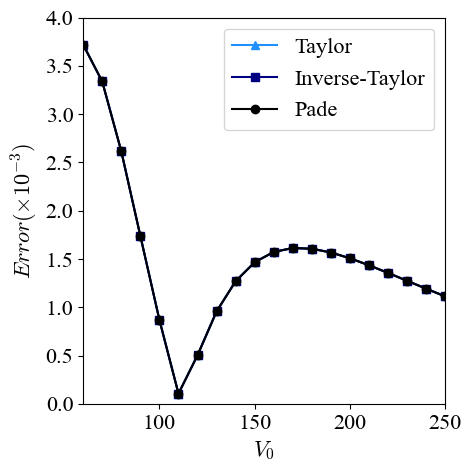

In [21]:
plt.figure(figsize=(5, 5))
plt.plot(V0, np.abs(Error["Taylor"]) * 1000, "^-", color="dodgerblue", label="Taylor")
plt.plot(V0, np.abs(Error["Inverse-Taylor"]) * 1000, "s-", color="navy", label="Inverse-Taylor")
plt.plot(V0, np.abs(Error["Pade"]) * 1000, "o-", color="k", label="Pade")
plt.xlabel(r"$V_0$")
plt.xlim(60, 250)
plt.ylabel(r"$Error (\times 10^{-3})$")
plt.ylim(0, 4)
plt.legend()
plt.tight_layout()
plt.show()

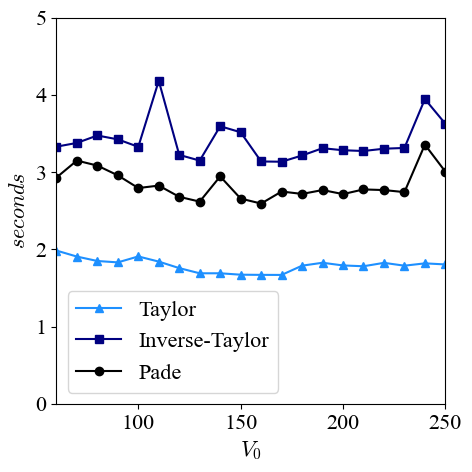

In [22]:
plt.figure(figsize=(5, 5))
plt.plot(V0, [ExecutionTime["Taylor"][potential] for potential in V0], "^-", color="dodgerblue", label="Taylor")
plt.plot(V0, [ExecutionTime["Inverse-Taylor"][potential] for potential in V0], "s-", color="navy", label="Inverse-Taylor")
plt.plot(V0, [ExecutionTime["Pade"][potential] for potential in V0], "o-", color="k", label="Pade")
plt.xlabel(r"$V_0$")
plt.xlim(60, 250)
plt.ylabel(r"$seconds$")
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()

## Discussion and Conclusion

The numerical experiments show that the three exponential propagators produce nearly identical physical results for the tested problems, while the approximation order has a clear influence on the accuracy of the harmonic-oscillator benchmark.

For the harmonic oscillator, increasing the approximation order from 4 to 8 substantially reduces the RMSE. With $N=2001$, the RMSE decreases from approximately $3.13\times10^{-1}$ at order 4 to $4.49\times10^{-3}$ at order 8. The observed convergence orders are approximately 3.9, 5.6, and 7.3 for orders 4, 6, and 8, respectively, confirming the expected high-order convergence of the numerical scheme.

The three propagators produce virtually identical RMSE values at each approximation order. Therefore, the accuracy of the harmonic-oscillator propagation is primarily determined by the approximation order rather than by the particular exponential representation used. Their computational costs, however, differ. The inverse-Taylor and Padé approximations require the solution of a matrix system, while the direct Taylor approximation only requires matrix multiplications. This additional operation results in higher execution times for the rational approximations in several of the tested cases.

For the tunnelling benchmark, the three propagators produce indistinguishable RMSE values for both barrier-thickness and barrier-height variations at the numerical precision considered. This indicates that, for the tested configurations and approximation order, the choice of exponential approximation has a negligible effect on the resulting transmission probability.

These results also highlight the distinction between the two numerical approximation layers used in the framework. The high-order central difference determines the approximation of the discrete Hamiltonian, while the Taylor, Inverse-Taylor, and Padé formulations determine how that Hamiltonian is propagated in time. Scaling and squaring is applied consistently to all three propagators, allowing their exponential approximations to be compared within the same computational framework.

Overall, this notebook demonstrates the progression from high-order finite-difference time propagation toward higher-order approximations of the matrix exponential. The resulting framework combines high-order spatial discretization with Taylor, Inverse-Taylor, and Padé exponential approximations under a common scaling-and-squaring procedure. The benchmarks demonstrate high-order convergence for the harmonic oscillator and consistent tunnelling results across variations in barrier thickness and height, while also showing the computational differences between polynomial and rational exponential approximations.